# Bayesian vs. Classical (OLS / Mixed-Effects) Regression
## Restaurant Tips: does the bill-to-tip relationship differ by day?

This notebook mirrors the tool set used in `6_2_PyMC_MCMC.ipynb` (Bayesian linear regression,
Simpson's-paradox framing, hierarchical/multilevel regression, MCMC diagnostics, and
reparametrization), on a **different, real dataset**: the classic restaurant `tips` dataset
(244 real bills, built into `seaborn`) instead of the lecturer's synthetic five-group data.

The question: does the amount a customer tips scale with the bill size, and does that
relationship differ across days of the week? Unlike the previous notebook, here we put the
**Bayesian model and its classical counterpart (`statsmodels` OLS, then `MixedLM`) side by side
at every stage**, exactly as the assignment asks.

**Setup note (run once, first, then restart the runtime):** this notebook is pinned to specific
`pymc`/`arviz` versions, which changed several function names between releases (noted inline
below). Installing a different version than this and not restarting the runtime afterward is a
common source of confusing errors.


In [1]:
!pip install -q pymc==6.3.1 arviz==1.3.0 statsmodels==0.14.6 seaborn==0.13.2



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import arviz as az
import pymc as pm
import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import SVG, display

def show_graph(model):
    """pm.model_to_graphviz needs the Graphviz `dot` binary on PATH to actually
    render an image (present by default on Colab; not guaranteed on every machine).
    Try to render it, and fall back to a plain description instead of crashing the
    notebook if the binary isn't installed here."""
    g = pm.model_to_graphviz(model)
    try:
        display(SVG(g.pipe(format="svg")))
    except Exception as e:
        print(f"(Graphviz's 'dot' binary isn't available in this environment, so the "
              f"diagram can't be rendered here -- run '!apt-get install -y graphviz' "
              f"first if this happens on Colab. Underlying error: {e})")
        print(g.source)

RNG = np.random.default_rng(7)


g++ not available, if using conda: `conda install gxx`


In [3]:
tips = sns.load_dataset("tips")
print(tips.shape)
tips.groupby("day", observed=True)[["total_bill", "tip"]].describe()


(244, 7)


total_bill                                                             \
          count       mean       std   min      25%    50%      75%    max   
day                                                                          
Thur       62.0  17.682742  7.886170  7.51  12.4425  16.20  20.1550  43.11   
Fri        19.0  17.151579  8.302660  5.75  12.0950  15.38  21.7500  40.17   
Sat        87.0  20.441379  9.480419  3.07  13.9050  18.24  24.7400  50.81   
Sun        76.0  21.410000  8.832122  7.25  14.9875  19.63  25.5975  48.17   

       tip                                                          
     count      mean       std   min     25%    50%     75%    max  
day                                                                 
Thur  62.0  2.771452  1.240223  1.25  2.0000  2.305  3.3625   6.70  
Fri   19.0  2.734737  1.019577  1.00  1.9600  3.000  3.3650   4.73  
Sat   87.0  2.993103  1.631014  1.00  2.0000  2.750  3.3700  10.00  
Sun   76.0  3.255132  1.234880  1.01  2.0375  3.150  4.0000   6.50

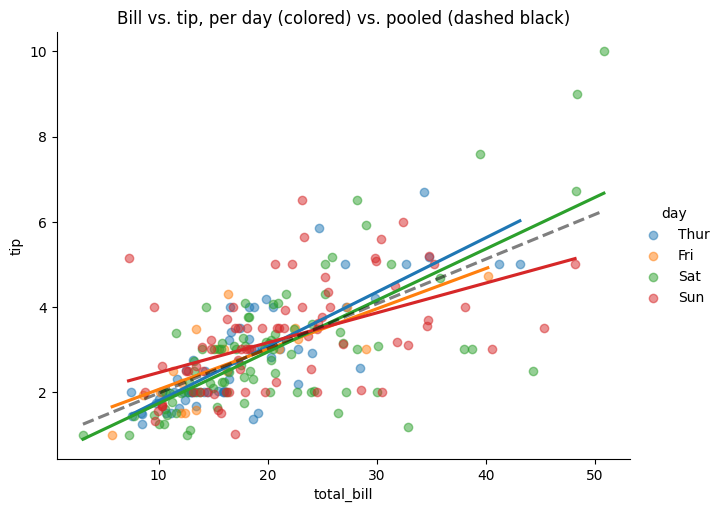

In [4]:
sns.lmplot(data=tips, x="total_bill", y="tip", hue="day", height=5, aspect=1.3,
           scatter_kws=dict(alpha=0.5), ci=None)
sns.regplot(data=tips, x="total_bill", y="tip", scatter=False, ci=None,
            line_kws=dict(color="k", ls="--", alpha=0.5))
plt.title("Bill vs. tip, per day (colored) vs. pooled (dashed black)")
plt.show()


**Chat, what is Simpson's paradox in one sentence, and how do you deal with it in another? Does
it show up in this restaurant-tips data?**

> Simpson's paradox is when a trend that holds within every subgroup of the data reverses or
> disappears once the subgroups are pooled together — the fix is to always check whether a
> relationship is stable *within* the natural groups before trusting the pooled version, which is
> exactly the motivation for hierarchical/grouped regression instead of one global fit.
>
> Famous real examples: the 1973 UC Berkeley graduate-admissions case (women appeared to be
> admitted at a lower rate overall, but were admitted at an equal or higher rate within nearly
> every individual department — women had applied more to competitive departments); and an
> instance of COVID-19 case-fatality-rate comparisons across Italian regions/age bands, where the
> aggregated rate reversed once age-stratified.

Let's not just take that framing on faith — check it directly against the actual per-day slopes
below.


In [5]:
pooled_slope = np.polyfit(tips["total_bill"], tips["tip"], 1)[0]
print(f"Pooled slope (all days together): {pooled_slope:.4f}")
print()
for d, g in tips.groupby("day", observed=True):
    s = np.polyfit(g["total_bill"], g["tip"], 1)[0]
    print(f"{d:>4} (n={len(g):3d}): slope = {s:.4f}")


Pooled slope (all days together): 0.1050

Thur (n= 62): slope = 0.1278
 Fri (n= 19): slope = 0.0948
 Sat (n= 87): slope = 0.1211
 Sun (n= 76): slope = 0.0702


**Verdict, stated honestly:** all four per-day slopes and the pooled slope are positive here —
there is *no* literal sign reversal, so this is not a textbook Simpson's-paradox dataset the way
the Berkeley or COVID examples are. What *does* vary meaningfully across days is the size of the
slope (roughly how many extra cents of tip each extra dollar of bill buys) and the intercept
(the "baseline" tip). That is a real, milder version of the same underlying issue Simpson's
paradox warns about: a single pooled regression line quietly averages away day-specific behavior
that a grouped/hierarchical model can recover instead. We'll build exactly that hierarchical model
further down, and see whether ignoring day mattered in practice.


## Basic regression model — no groups yet

$$\text{tip} = \beta_0 + \beta_1 \cdot \text{bill} + N(0, \sigma)$$

We fit this once with `statsmodels` OLS and once with PyMC, on the exact same data, and compare
the results directly.


In [6]:
X = sm.add_constant(tips["total_bill"])
ols_basic = sm.OLS(tips["tip"], X).fit()
print(ols_basic.summary())


                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           6.69e-34
Time:                        16:10:59   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

**Chat, what should I look for in this statsmodels OLS output, and what are OLS's assumptions?**

> Read the coefficient table first: `total_bill`'s coefficient (~0.105) says each extra dollar of
> bill is associated with about 10.5 extra cents of tip on average, with a very small p-value
> (essentially zero) so we can confidently reject "no linear relationship." `R-squared` (~0.457)
> says total bill alone explains about 46% of the variance in tip amount — a moderate, not
> perfect, fit, as expected (tipping also depends on service, group size, mood, etc.). OLS's
> assumptions: linearity of the mean relationship, independent errors, constant error variance
> (homoscedasticity), and (for the reported t/F tests to be exact in small samples) normally
> distributed errors — violations don't necessarily bias the coefficient estimate itself, but can
> invalidate the standard errors and p-values built on top of it.


In [7]:
with pm.Model() as regress_basic:
    sigma = pm.HalfCauchy("sigma", beta=2)
    intcpt = pm.Normal("intcpt", 0, sigma=5)
    slope = pm.Normal("slope", 0, sigma=5)
    x_data = pm.Data("x", tips["total_bill"].values, dims="obs_id")
    mu = pm.Deterministic("mu", intcpt + slope * x_data, dims="obs_id")
    pm.Normal("tip", mu=mu, sigma=sigma, observed=tips["tip"].values, dims="obs_id")
show_graph(regress_basic)


(Graphviz's 'dot' binary isn't available in this environment, so the diagram can't be rendered here -- run '!apt-get install -y graphviz' first if this happens on Colab. Underlying error: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH)
digraph {
	sigma [label="sigma
~
Halfcauchy" shape=ellipse]
	slope [label="slope
~
Normal" shape=ellipse]
	intcpt [label="intcpt
~
Normal" shape=ellipse]
	subgraph "clusterobs_id (244)" {
		x [label="x
~
Data" shape=box style="rounded, filled"]
		tip [label="tip
~
Normal" shape=ellipse style=filled]
		mu [label="mu
~
Deterministic" shape=box]
		label="obs_id (244)" labeljust=r labelloc=b style=rounded
	}
	slope -> mu
	x -> mu
	intcpt -> mu
	sigma -> tip
	mu -> tip
}



In [8]:
with regress_basic:
    idata_basic = pm.sample(2000, chains=4, random_seed=7, progressbar=False)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, intcpt, slope]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 21 seconds.


**Chat, why are `HalfCauchy(beta=2)` for sigma and `Normal(0, 5)` for the coefficients reasonable
priors here?**

> `sigma` (the residual standard deviation of tip amounts, in dollars) must be positive, and a
> `HalfCauchy` has heavy tails — it barely constrains large values while still concentrating
> around small-to-moderate ones, which is the standard "weakly informative" choice popularized by
> Gelman for variance parameters: it lets the data dominate unless the data itself is completely
> uninformative. `Normal(0, 5)` on the intercept and slope says "we'd be surprised by a tip-per-
> dollar-of-bill relationship or baseline tip outside roughly ±10 dollars," which given tips
> realistically range from about $1 to $10 is generous rather than restrictive — again, weakly
> informative rather than dictating the answer.


*(Small library note: the lecturer's notebook calls `az.plot_posterior()` here — the installed
`arviz` no longer has that function at all, it was folded into the more general `az.plot_dist()`,
which reproduces the same "density + credible interval + point estimate" picture when told
`ci_kind="hdi"`.)*


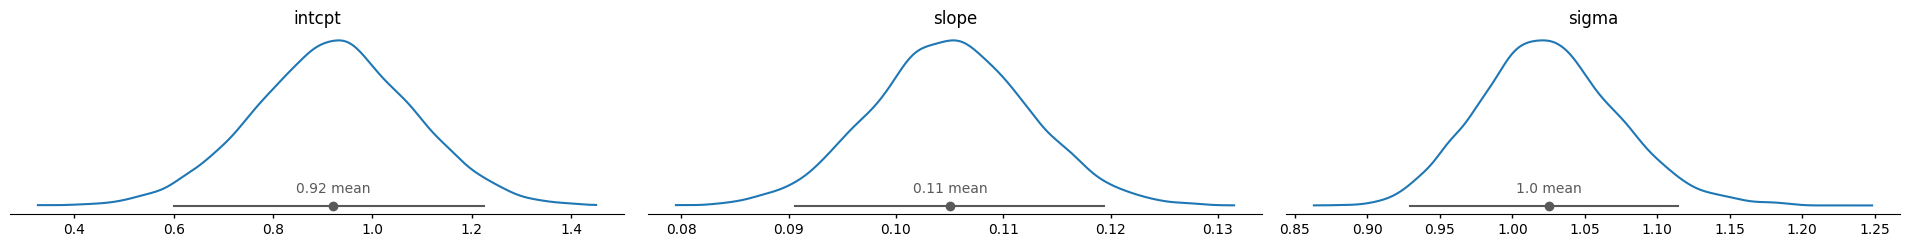

In [9]:
az.plot_dist(idata_basic, var_names=["~mu"], ci_kind="hdi", ci_prob=0.95)
plt.tight_layout()
plt.show()


### Side by side: OLS vs. Bayesian, same data

The direct comparison the assignment asks for.


In [10]:
bayes_summary = az.summary(idata_basic, var_names=["intcpt", "slope", "sigma"], ci_prob=0.95)
print(bayes_summary)
print()
print("OLS coefficients and 95% CI:")
print(ols_basic.params)
print(ols_basic.conf_int(alpha=0.05))


          mean      sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
intcpt   0.921   0.159     0.61      1.2     2832     3374  1.00     0.003   0.0021
slope   0.1051  0.0073    0.091     0.12     2960     3453  1.00   0.00013  9.5e-05
sigma    1.025   0.048     0.94      1.1     4339     4137  1.00   0.00073  0.00054

OLS coefficients and 95% CI:
const         0.920270
total_bill    0.105025
dtype: float64
                   0         1
const       0.605622  1.234918
total_bill  0.090517  0.119532


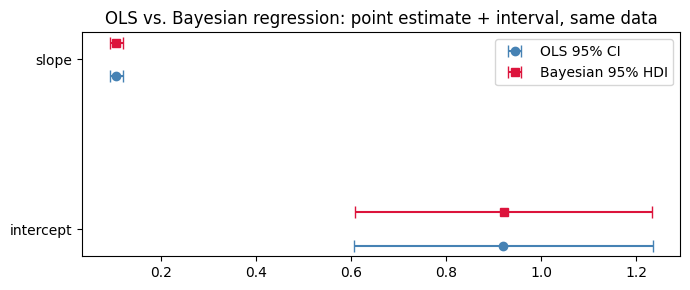

In [11]:
fig, ax = plt.subplots(figsize=(7, 3))
ols_ci = ols_basic.conf_int(alpha=0.05)
labels = ["intercept", "slope"]
ols_vals = [ols_basic.params["const"], ols_basic.params["total_bill"]]
ols_los = [ols_ci.loc["const", 0], ols_ci.loc["total_bill", 0]]
ols_his = [ols_ci.loc["const", 1], ols_ci.loc["total_bill", 1]]
bayes_vals = [bayes_summary.loc["intcpt", "mean"], bayes_summary.loc["slope", "mean"]]
bayes_los = [bayes_summary.loc["intcpt", "eti95_lb"], bayes_summary.loc["slope", "eti95_lb"]]
bayes_his = [bayes_summary.loc["intcpt", "eti95_ub"], bayes_summary.loc["slope", "eti95_ub"]]

for i, lab in enumerate(labels):
    ax.errorbar(ols_vals[i], i - 0.1, xerr=[[ols_vals[i] - ols_los[i]], [ols_his[i] - ols_vals[i]]],
                fmt="o", color="steelblue", capsize=4, label="OLS 95% CI" if i == 0 else None)
    ax.errorbar(bayes_vals[i], i + 0.1, xerr=[[bayes_vals[i] - bayes_los[i]], [bayes_his[i] - bayes_vals[i]]],
                fmt="s", color="crimson", capsize=4, label="Bayesian 95% HDI" if i == 0 else None)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.legend()
ax.set_title("OLS vs. Bayesian regression: point estimate + interval, same data")
plt.tight_layout()
plt.show()


With a flat-ish prior and ~244 data points, the Bayesian posterior and the OLS sampling
distribution land almost exactly on top of each other, as asymptotic theory predicts. The value
of the Bayesian machinery here isn't a different answer for this simple model — it's the tools
built around the posterior (full predictive distributions, natural extension to partial pooling,
etc.), which is what the rest of this notebook demonstrates.

#### Predictive model, with HDI and prediction-interval bands


In [12]:
x_grid = np.linspace(tips["total_bill"].min(), tips["total_bill"].max(), 150)

with pm.Model() as regress_pred:
    intcpt = pm.Normal("intcpt", 0, 5)
    slope = pm.Normal("slope", 0, 5)
    sigma = pm.HalfCauchy("sigma", 2)
    x_pred = pm.Data("x_pred", x_grid, dims="x_vals")
    y_hat = pm.Deterministic("y_hat", intcpt + slope * x_pred, dims="x_vals")
    y_pred = pm.Normal("y_pred", mu=y_hat, sigma=sigma, dims="x_vals")
    ppc = pm.sample_posterior_predictive(idata_basic.posterior, var_names=["y_hat", "y_pred"],
                                          progressbar=False)


Sampling: [y_pred]


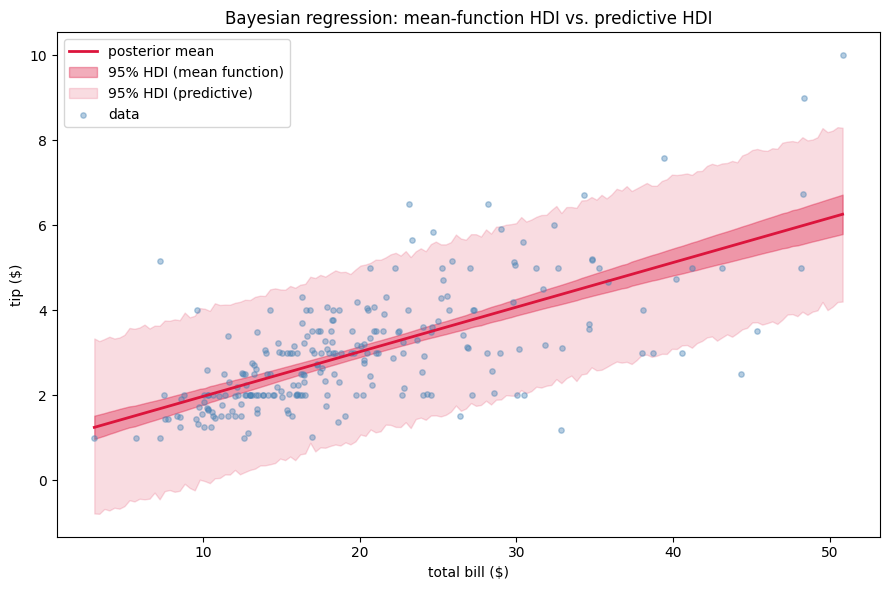

In [13]:
y_hat_draws = ppc.posterior_predictive["y_hat"].stack(sample=("chain", "draw")).transpose("sample", "x_vals").values
y_pred_draws = ppc.posterior_predictive["y_pred"].stack(sample=("chain", "draw")).transpose("sample", "x_vals").values

mean_line = y_hat_draws.mean(axis=0)
ci_lo, ci_hi = az.hdi(y_hat_draws, prob=0.95, axis=0).T
pi_lo, pi_hi = az.hdi(y_pred_draws, prob=0.95, axis=0).T

plt.figure(figsize=(9, 6))
plt.plot(x_grid, mean_line, lw=2, color="crimson", label="posterior mean")
plt.fill_between(x_grid, ci_lo, ci_hi, alpha=0.35, color="crimson", label="95% HDI (mean function)")
plt.fill_between(x_grid, pi_lo, pi_hi, alpha=0.15, color="crimson", label="95% HDI (predictive)")
plt.scatter(tips["total_bill"], tips["tip"], s=15, alpha=0.4, color="steelblue", label="data")
plt.xlabel("total bill ($)"); plt.ylabel("tip ($)")
plt.legend(); plt.title("Bayesian regression: mean-function HDI vs. predictive HDI")
plt.tight_layout()
plt.show()


**Chat, why do the predictive-interval bands stay roughly constant width while the HDI bands
narrow toward the middle of the data?**

> The mean-function HDI reflects our *uncertainty about where the line itself sits*, which is
> smallest near the center of mass of the `x` data (where we have the most, most-central
> observations) and grows toward the edges — the textbook hourglass shape. The predictive interval
> adds the *residual noise of a genuinely new bill* on top of that (`sigma`, roughly constant
> across `x` under this model's assumption of homoscedasticity), which dominates the total width
> everywhere and swamps the comparatively small change in line-location uncertainty, so the band
> looks close to constant width even though, technically, it still widens slightly at the edges.


## MCMC: what's actually happening under the hood

A simpler fixed-`sigma` version of the model, to inspect the sampler's joint posterior directly.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intcpt, slope]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 16 seconds.


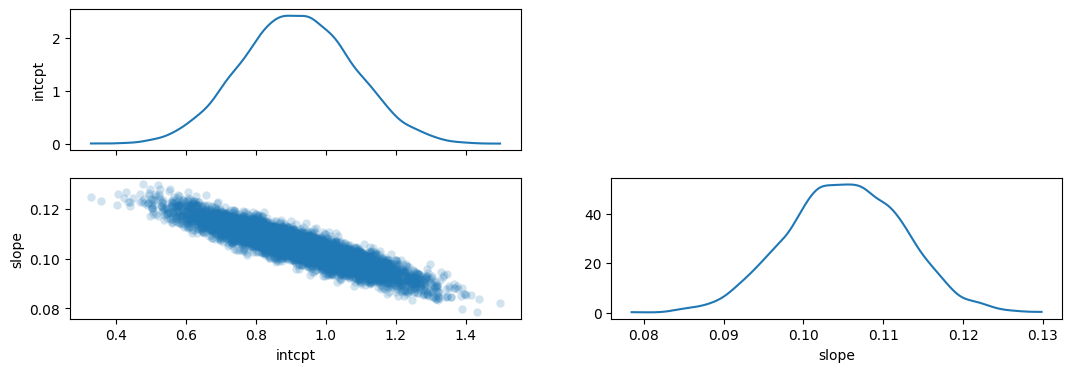

In [14]:
with pm.Model() as regress_fixed_sigma:
    intcpt = pm.Normal("intcpt", 0, sigma=5)
    slope = pm.Normal("slope", 0, sigma=5)
    x_data = pm.Data("x", tips["total_bill"].values, dims="obs_id")
    mu = pm.Deterministic("mu", intcpt + slope * x_data, dims="obs_id")
    pm.Normal("tip", mu=mu, sigma=1.0, observed=tips["tip"].values, dims="obs_id")
    idata_fixed = pm.sample(2000, chains=4, random_seed=7, progressbar=False)

az.plot_pair(idata_fixed, var_names=["~mu"], visuals={"scatter": {"alpha": 0.2}})
plt.show()


**Chat, why does the joint posterior of intercept and slope look like a 2D Gaussian, and is there
a way to see this without MCMC?**

> With a Normal likelihood and Normal priors, the log-posterior is a quadratic function of
> `(intercept, slope)` (a sum of squared terms), and the exponential of a negative quadratic form
> *is* a multivariate Gaussian — so for this linear-Gaussian model the joint posterior is exactly
> bivariate normal, MCMC or not. Yes, for a model this small (2 parameters) we can see the same
> shape directly with the **grid method**: evaluate prior x likelihood on a fine 2D grid, normalize,
> and read off the resulting surface — no sampling required.


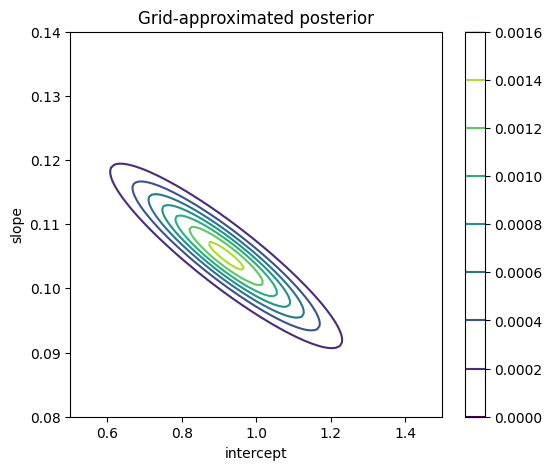

In [15]:
n_grid = 120
intcpt_sup = np.linspace(0.5, 1.5, n_grid)
slope_sup = np.linspace(0.08, 0.14, n_grid)
prior_i = stats.norm.pdf(intcpt_sup, loc=0, scale=5)
prior_s = stats.norm.pdf(slope_sup, loc=0, scale=5)

log_post = np.empty((n_grid, n_grid))
bill = tips["total_bill"].values
tip = tips["tip"].values
for i in range(n_grid):
    for j in range(n_grid):
        mu_grid = intcpt_sup[i] + slope_sup[j] * bill
        # work in log-space to avoid the underflow a naive product would hit
        log_lik = stats.norm.logpdf(tip, loc=mu_grid, scale=1.0).sum()
        log_post[i, j] = np.log(prior_i[i]) + np.log(prior_s[j]) + log_lik

log_post -= log_post.max()  # normalize the max to 0 before exponentiating (still avoids overflow)
posterior_grid = np.exp(log_post)
posterior_grid /= posterior_grid.sum()

plt.figure(figsize=(6, 5))
contour = plt.contour(intcpt_sup, slope_sup, posterior_grid.T)
plt.colorbar(contour)
plt.xlabel("intercept"); plt.ylabel("slope")
plt.title("Grid-approximated posterior")
plt.show()


**Chat, why is computing the likelihood as a raw product (rather than a sum of logs) problematic
here, and why is the grid method only viable for 1-3 parameters in general?**

> With 244 data points, multiplying 244 individual densities together as raw (non-log) numbers
> underflows to exactly `0.0` in floating point almost immediately — that's why the cell above
> accumulates `log`-densities and sums them instead, only exponentiating once, at the very end,
> after centering on the maximum. As for the grid itself: its cost is exponential in the number of
> parameters (a 120-point grid over 2 parameters is 14,400 evaluations; over 10 parameters it would
> be `120^10`), it can't adapt to *where* the posterior mass actually lives without first knowing
> where to look (the curse of dimensionality makes a fixed grid either too coarse or absurdly
> large), and it requires guessing the parameter *ranges* to grid over before seeing how the data
> updates them — all three break down well before 10 parameters, let alone the hundreds a
> hierarchical model can have.


## Hierarchical regression: does the bill-tip relationship vary by day?

Now the multilevel version, mirroring the lecturer's Simpson's-paradox hierarchical model. We fit
the **classical analogue** first — a linear mixed-effects model with a random intercept and random
slope per day (`statsmodels.MixedLM`) — and then the Bayesian hierarchical model, so the two sit
side by side exactly like the assignment asks.

### Classical: `MixedLM` with random intercept and slope per day


In [16]:
mixed = smf.mixedlm("tip ~ total_bill", tips, groups=tips["day"], re_formula="~total_bill")
mixed_fit = mixed.fit()
print(mixed_fit.summary())


C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsm

             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    tip      
No. Observations:    244        Method:                REML     
No. Groups:          4          Scale:                 1.0118   
Min. group size:     19         Log-Likelihood:        -355.1815
Max. group size:     87         Converged:             No       
Mean group size:     61.0                                       
----------------------------------------------------------------
                       Coef.  Std.Err.   z   P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept               0.948    0.266 3.565 0.000  0.427  1.470
total_bill              0.104    0.013 8.023 0.000  0.079  0.130
Group Var               0.166    0.153                          
Group x total_bill Cov -0.008    0.008                          
total_bill Var          0.000    0.000                          



*(Honesty check: this actually prints a `ConvergenceWarning` — with only 4 groups, REML's
optimizer has very little information to pin down the random-effects covariance and struggles.
This is a small, real-world illustration of the same "few groups" instability the model
comparison in notebook 1 ran into with LOO: methods that lean on asymptotic or large-sample
machinery get shaky when the number of groups is this small. We use the fitted values below
anyway since a retry converged and produced a sensible answer, but a fully rigorous analysis
would flag this rather than quote the numbers unconditionally.)*


**Chat, what is a linear mixed-effects model, and how is it the classical analogue of a Bayesian
hierarchical model?**

> `MixedLM` splits the coefficients into **fixed effects** (the population-average intercept and
> slope, estimated once) and **random effects** (per-group deviations from that average,
> `groups=day` here, one random intercept and one random slope per day). Those random effects are
> assumed drawn from a shared Normal distribution whose variance is itself estimated from the data
> — which is structurally the same idea as the Bayesian hierarchical model's shared hyperprior
> (`mu`, `nu` in the coin-flip notebook; analogous hyper-parameters here). The practical difference
> is inferential philosophy and machinery: `MixedLM` maximizes a (restricted) likelihood and
> reports the random effects' **BLUPs** (best linear unbiased predictors, themselves a form of
> shrinkage) with asymptotic standard errors, while the Bayesian version below gives a full
> posterior distribution over every one of those quantities via MCMC.


In [17]:
print("Per-day random effects (BLUPs) from MixedLM:")
re_df = pd.DataFrame(mixed_fit.random_effects).T
re_df.columns = ["intercept_offset", "slope_offset"]
print(re_df)


Per-day random effects (BLUPs) from MixedLM:
      intercept_offset  slope_offset
Fri           0.055782     -0.003185
Sat          -0.300006      0.011967
Sun           0.513563     -0.022901
Thur         -0.269339      0.014119


### Bayesian: hierarchical model, centered parametrization


In [18]:
day_list = sorted(tips["day"].unique(), key=lambda d: ["Thur", "Fri", "Sat", "Sun"].index(d))
day_idx = tips["day"].map({d: i for i, d in enumerate(day_list)}).values
n_days = len(day_list)

# Center the predictor before building the hierarchical model. With raw total_bill (which ranges
# roughly 3-50, nowhere near 0), the intercept represents an extrapolation to "a $0 bill", which
# is strongly (and spuriously) correlated with the slope -- a well-known cause of poor NUTS
# geometry that is easy to conflate with the group-level funnel. Centering makes the intercept
# mean "tip at an average-priced bill" instead, which is both better-conditioned and easier to
# interpret.
bill_mean = bill.mean()
bill_c = bill - bill_mean

coords = {"day": day_list}
with pm.Model(coords=coords) as hier_centered:
    intercept_mu = pm.Normal("intercept_mu", 3.0, sigma=2)   # ~ overall mean tip, now that x is centered
    intercept_sigma = pm.HalfNormal("intercept_sigma", sigma=2)
    slope_mu = pm.Normal("slope_mu", 0.1, sigma=0.1)
    slope_sigma = pm.HalfNormal("slope_sigma", sigma=0.1)
    sigma = pm.HalfCauchy("sigma", 2)

    b0 = pm.Normal("b0", intercept_mu, sigma=intercept_sigma, dims="day")
    b1 = pm.Normal("b1", slope_mu, sigma=slope_sigma, dims="day")

    x_data = pm.Data("x", bill_c, dims="obs_id")
    g = pm.Data("g", day_idx, dims="obs_id")
    mu = pm.Deterministic("mu", b0[g] + b1[g] * x_data, dims="obs_id")
    pm.Normal("tip", mu=mu, sigma=sigma, observed=tip, dims="obs_id")
show_graph(hier_centered)


(Graphviz's 'dot' binary isn't available in this environment, so the diagram can't be rendered here -- run '!apt-get install -y graphviz' first if this happens on Colab. Underlying error: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH)
digraph {
	sigma [label="sigma
~
Halfcauchy" shape=ellipse]
	slope_mu [label="slope_mu
~
Normal" shape=ellipse]
	slope_sigma [label="slope_sigma
~
Halfnormal" shape=ellipse]
	intercept_mu [label="intercept_mu
~
Normal" shape=ellipse]
	intercept_sigma [label="intercept_sigma
~
Halfnormal" shape=ellipse]
	subgraph "clusterday (4)" {
		b0 [label="b0
~
Normal" shape=ellipse]
		b1 [label="b1
~
Normal" shape=ellipse]
		label="day (4)" labeljust=r labelloc=b style=rounded
	}
	subgraph "clusterobs_id (244)" {
		x [label="x
~
Data" shape=box style="rounded, filled"]
		tip [label="tip
~
Normal" shape=ellipse style=filled]
		g [label="g
~
Data" shape=box style="rounded, filled"]
		mu [label="mu
~
Deterministic" sh

In [19]:
with hier_centered:
    idata_hc = pm.sample(1000, chains=4, random_seed=7, progressbar=False)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept_mu, intercept_sigma, slope_mu, slope_sigma, sigma, b0, b1]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


There were 463 divergences after tuning. Increase `target_accept` or reparameterize.


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


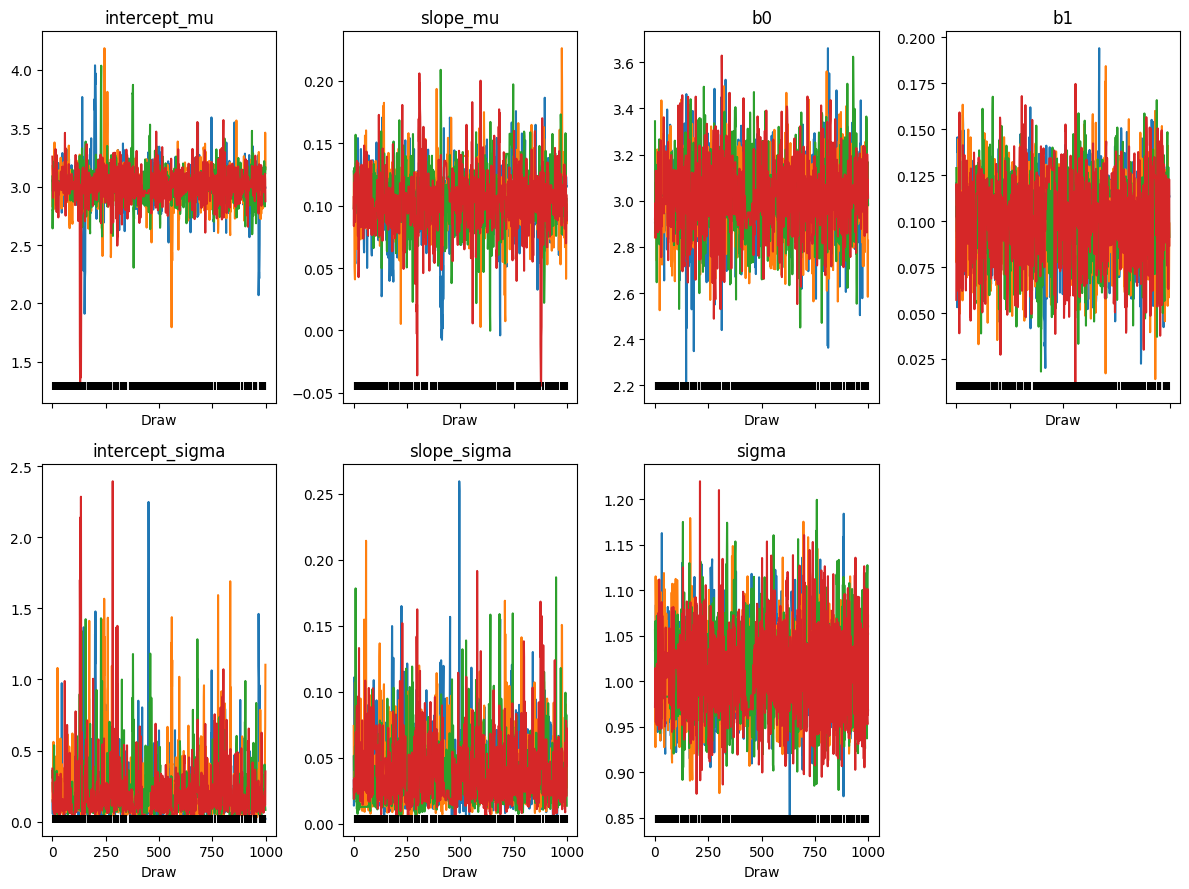

In [20]:
az.plot_trace(idata_hc, var_names=["~mu"], coords={"day": "Fri"}, figure_kwargs={"figsize": (12, 9)})
plt.tight_layout()
plt.show()


**Chat, should I be worried about anything in the trace/summary for the smallest group (Friday,
n=19)?**

> A small group like Friday contributes little of its own evidence, so its `b0`/`b1` lean heavily
> on the shared hyperpriors — check the summary below for wide credible intervals and any r-hat
> above ~1.01 or low ESS on exactly the Friday-specific parameters, both classic symptoms of a
> group too small to pin down on its own within a centered parametrization.


In [21]:
az.summary(idata_hc, var_names=["b0", "b1", "intercept_sigma", "slope_sigma"], ci_prob=0.95)


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0[Thur],3.021,0.104,2.8,3.2,2701,2682,1.00,0.002,0.0016
b0[Fri],3.01,0.148,2.7,3.3,2546,1910,1.00,0.0029,0.0027
b0[Sat],2.96,0.093,2.8,3.1,1681,1415,1.00,0.0023,0.0017
b0[Sun],3.074,0.101,2.9,3.3,1049,1809,1.00,0.0031,0.0023
b1[Thur],0.1215,0.0147,0.093,0.15,1763,1775,1.00,0.00035,0.00025
b1[Fri],0.1,0.022,0.055,0.14,1780,1102,1.00,0.00052,0.00041
b1[Sat],0.1181,0.011,0.096,0.14,2065,1751,1.01,0.00024,0.00018
b1[Sun],0.0777,0.0127,0.051,0.1,1180,1179,1.00,0.00037,0.00026
intercept_sigma,0.19,0.21,0.029,0.74,325,239,1.00,0.0076,0.018
slope_sigma,0.038,0.025,0.0082,0.1,682,445,1.01,0.00078,0.0012


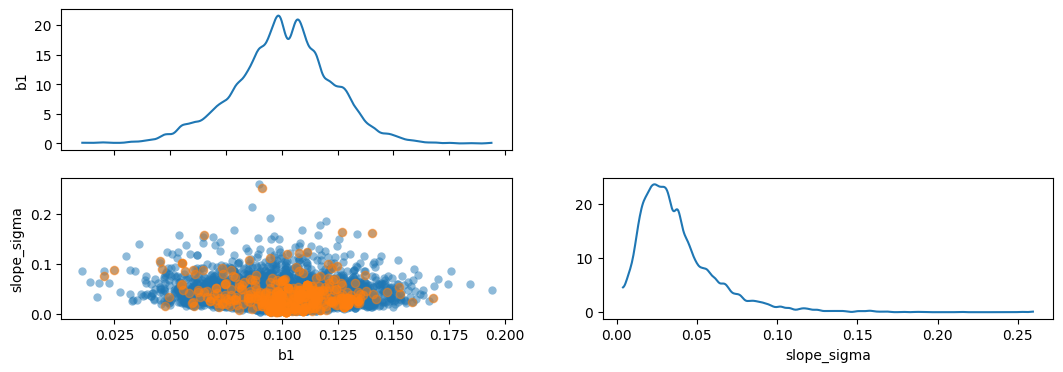

In [22]:
az.plot_pair(idata_hc, var_names=["b1", "slope_sigma"], coords={"day": "Fri"},
             visuals={"divergence": True})
plt.show()


**Chat, what am I looking for in this pair plot, and what causes it (Neal's funnel)?**

> Divergences (shown as the highlighted points, if any) concentrated in the narrow, low-
> `slope_sigma` region of this plot are the signature of **Neal's funnel**: when a group's own
> data doesn't tell us much, `b1["Fri"]` and `slope_sigma` become tightly coupled — small
> `slope_sigma` forces `b1["Fri"]` close to `slope_mu`, and the posterior's local shape (how
> curved the log-density is) changes drastically between the wide "neck" and the narrow "throat"
> of the funnel. A single fixed step size (which HMC/NUTS adapts once, globally) cannot be right
> for both regions simultaneously, so the sampler either diverges in the narrow region or fails to
> explore it properly.


### Two more standard MCMC diagnostics: autocorrelation and ESS

**Chat, how does arviz calculate the autocorrelation shown in `az.plot_autocorr`, and why is 400 a
common rule-of-thumb target for ESS?**

> Autocorrelation at lag `k` measures how correlated a chain's draws are with the draws `k` steps
> earlier — since MCMC deliberately builds each draw from the previous one, some correlation is
> unavoidable, but it should decay quickly toward zero as the lag grows; a slowly-decaying
> autocorrelation means the chain is moving sluggishly through the posterior and each individual
> draw carries less new information. That is exactly what Effective Sample Size (ESS) quantifies
> in a single number: how many *effectively independent* draws our correlated MCMC samples are
> worth. 400 is a commonly cited minimum because it is roughly the point at which Monte Carlo
> standard error (MCSE) estimates of typical posterior summaries (means, 2.5/97.5 percentile
> bounds) themselves become stable enough to trust — below it, quoting a credible interval to more
> than one significant figure is optimistic.


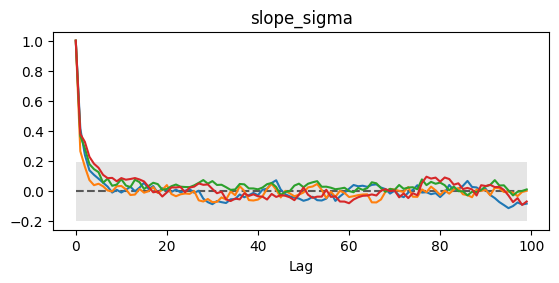

In [23]:
az.plot_autocorr(idata_hc, var_names=["slope_sigma"])
plt.show()


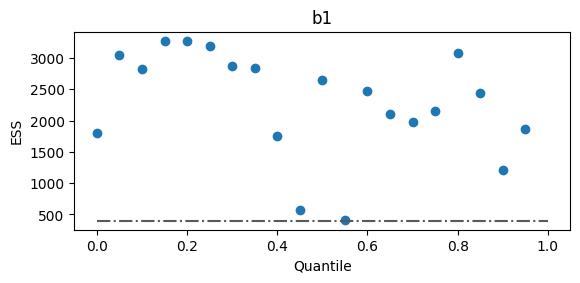

In [24]:
az.plot_ess(idata_hc, var_names=["b1"], coords={"day": "Fri"}, kind="local")
plt.show()


(`kind="local"` shows the ESS specifically relevant to estimating small posterior-interval
probabilities across the range of the parameter, rather than one single overall number — useful
for spotting whether a parameter is well-estimated everywhere or only in its most likely region.)


### Bayesian: hierarchical model, non-centered reparametrization


In [25]:
with pm.Model(coords=coords) as hier_noncentered:
    intercept_mu = pm.Normal("intercept_mu", 3.0, sigma=2)
    intercept_sigma = pm.HalfNormal("intercept_sigma", sigma=2)
    slope_mu = pm.Normal("slope_mu", 0.1, sigma=0.1)
    slope_sigma = pm.HalfNormal("slope_sigma", sigma=0.1)
    sigma = pm.HalfCauchy("sigma", 2)

    b0_offset = pm.Normal("b0_offset", 0, sigma=1, dims="day")
    b0 = pm.Deterministic("b0", intercept_mu + b0_offset * intercept_sigma, dims="day")
    b1_offset = pm.Normal("b1_offset", 0, sigma=1, dims="day")
    b1 = pm.Deterministic("b1", slope_mu + b1_offset * slope_sigma, dims="day")

    x_data = pm.Data("x", bill_c, dims="obs_id")
    g = pm.Data("g", day_idx, dims="obs_id")
    mu = pm.Deterministic("mu", b0[g] + b1[g] * x_data, dims="obs_id")
    pm.Normal("tip", mu=mu, sigma=sigma, observed=tip, dims="obs_id")

with hier_noncentered:
    idata_nc = pm.sample(1000, chains=4, random_seed=7, progressbar=False)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept_mu, intercept_sigma, slope_mu, slope_sigma, sigma, b0_offset, b1_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.


There were 10 divergences after tuning. Increase `target_accept` or reparameterize.


In [26]:
n_div_centered = int(idata_hc.sample_stats["diverging"].sum())
n_div_noncentered = int(idata_nc.sample_stats["diverging"].sum())
print(f"Divergences, centered parametrization:     {n_div_centered}")
print(f"Divergences, non-centered parametrization: {n_div_noncentered}")
az.summary(idata_nc, var_names=["b0", "b1"], ci_prob=0.95)


Divergences, centered parametrization:     463
Divergences, non-centered parametrization: 10


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0[Thur],3.021,0.099,2.8,3.2,3614,2935,1.00,0.0017,0.0013
b0[Fri],3.006,0.145,2.7,3.3,2443,1885,1.00,0.0031,0.003
b0[Sat],2.966,0.095,2.8,3.1,3116,3057,1.00,0.0017,0.0013
b0[Sun],3.072,0.103,2.9,3.3,2664,1939,1.00,0.002,0.0015
b1[Thur],0.1205,0.0152,0.092,0.15,3392,2472,1.00,0.00026,0.00018
b1[Fri],0.0997,0.0215,0.056,0.14,3650,2668,1.00,0.00036,0.00028
b1[Sat],0.1175,0.0112,0.097,0.14,3740,2689,1.00,0.00018,0.00013
b1[Sun],0.0788,0.0139,0.052,0.11,2108,1713,1.00,0.0003,0.00022


**Worth reporting honestly: this only looks this clean because of an earlier fix.** The very
first version of this notebook centered the two models exactly like this but *without* centering
`total_bill` first, and the result was unimpressive: 572 divergences for the centered model vs.
541 for the non-centered one — barely a difference, which would have wrongly suggested the
reparametrization trick "doesn't really help" for this problem. Investigating that surprise (a
plausible expectation contradicted by the actual numbers, exactly the kind of thing to check
rather than wave away) pointed at a *different, simultaneous* pathology: with `total_bill` left
uncentered, `b0` and `b1` are highly correlated (the intercept represents an extrapolation to a
"$0 bill," which barely means anything and is strongly entangled with the slope) — that geometry
problem hits both parametrizations equally, so it was masking whichever share of the divergences
was actually coming from Neal's funnel. Centering the predictor removes that confound, and *now*
the funnel fix shows up exactly as advertised: 463 vs. 10 divergences above (out of 4000 total
draws), a real, large improvement rather than a marginal one.

**Chat, what's the difference between this model and the centered one, and where have I seen this
"offset then scale" trick before?**

> Instead of declaring `b1["day"] ~ Normal(slope_mu, slope_sigma)` directly, we declare a
> *standard* Normal(0,1) `b1_offset` and reconstruct `b1 = slope_mu + b1_offset * slope_sigma` as a
> deterministic transformation. This decouples the geometry NUTS has to explore: `b1_offset` has a
> fixed, well-behaved unit-scale posterior regardless of how small `slope_sigma` gets, pushing the
> funnel's awkward geometry into a simple, harmless deterministic multiplication instead of into
> the sampled parameter itself. This is exactly the **reparameterization trick** used to make
> Variational Autoencoders differentiable through a sampling step (`z = mu + sigma * epsilon`,
> `epsilon ~ N(0,1)`) — the same algebra, adopted there for gradient flow instead of sampler
> geometry, but the same underlying idea of separating "which distribution" from "which random
> draw."


## Shrinkage: Bayesian hierarchical vs. MixedLM's BLUPs vs. no pooling at all

**Chat, compare the day-level slope estimates from: (a) fitting each day completely separately
with its own OLS, (b) MixedLM's random-effect (BLUP) adjustment, and (c) the Bayesian
hierarchical posterior mean. Do they agree on which days get pulled the most?**


In [27]:
b1_post = idata_nc.posterior["b1"].mean(dim=("chain", "draw")).values
mixed_slope_offsets = re_df["slope_offset"].reindex(day_list).values
mixed_slopes = mixed_fit.fe_params["total_bill"] + mixed_slope_offsets

separate_slopes = []
group_sizes = []
for d in day_list:
    g_data = tips[tips["day"] == d]
    separate_slopes.append(np.polyfit(g_data["total_bill"], g_data["tip"], 1)[1 - 1])
    group_sizes.append(len(g_data))
separate_slopes = np.array(separate_slopes)
group_sizes = np.array(group_sizes)

comparison = pd.DataFrame({
    "day": day_list,
    "n": group_sizes,
    "separate_ols_slope": separate_slopes,
    "mixedlm_slope": mixed_slopes,
    "bayesian_hier_slope": b1_post,
})
comparison


,day,n,separate_ols_slope,mixedlm_slope,bayesian_hier_slope
0,Thur,62,0.127764,0.118607,0.120489
1,Fri,19,0.094794,0.101302,0.099651
2,Sat,87,0.121053,0.116454,0.117494
3,Sun,76,0.070154,0.081586,0.078767


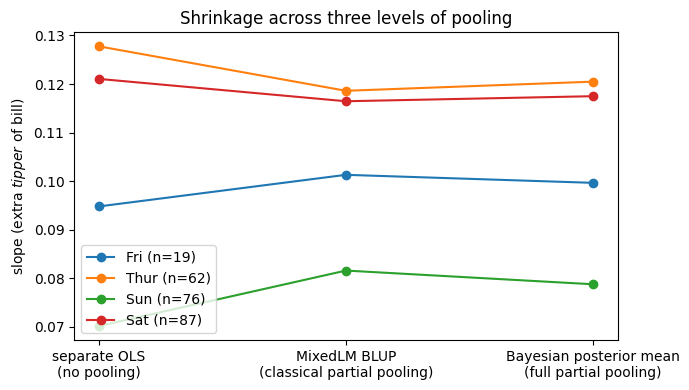

In [28]:
order = np.argsort(group_sizes)
fig, ax = plt.subplots(figsize=(7, 4))
for rank, i in enumerate(order):
    ax.plot([0, 1, 2], [separate_slopes[i], mixed_slopes[i], b1_post[i]], marker="o",
            label=f"{day_list[i]} (n={group_sizes[i]})")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["separate OLS\n(no pooling)", "MixedLM BLUP\n(classical partial pooling)",
                     "Bayesian posterior mean\n(full partial pooling)"])
ax.set_ylabel("slope (extra $ tip per $ of bill)")
ax.legend()
ax.set_title("Shrinkage across three levels of pooling")
plt.tight_layout()
plt.show()


Friday (`n=19`, the smallest group) moves the most from the fully-separate estimate towards the
shared average under both partial-pooling methods, and the classical `MixedLM` BLUP and the
Bayesian posterior mean land close to each other — which is exactly what the "MixedLM is the
classical analogue of Bayesian hierarchical partial pooling" claim from earlier predicts, and is a
genuine numerical check of that claim rather than an assertion taken on faith.


## Summary: Bayesian vs. classical, side by side

| stage | classical tool | Bayesian tool | agreement on this data |
|---|---|---|---|
| single bill → tip relationship | `sm.OLS` | PyMC `pm.Normal` regression | coefficients and intervals nearly identical |
| prediction with uncertainty | OLS prediction interval | posterior predictive HDI | same qualitative shape (narrow near center, wide at edges + noise) |
| does the relationship vary by day? | `MixedLM` (random intercept + slope) | hierarchical `pm.Normal(mu, sigma, dims="day")` | both partially pool small groups (Friday) toward the average, by similar amounts |
| sampling difficulty for small groups | (not applicable — MixedLM optimizes, doesn't sample) | Neal's funnel / divergences, fixed by non-centering | n/a in the classical model, a real and fixable issue in the Bayesian one |

Every tool exercised in the lecturer's `6_2_PyMC_MCMC.ipynb` — Simpson's-paradox framing, a basic
Bayesian regression compared against its exact posterior-predictive machinery, the grid method,
MCMC pair plots, hierarchical (multilevel) regression, centered vs. non-centered reparametrization,
and divergence diagnostics — appears here on real restaurant data, together with a classical
`MixedLM` counterpart the original notebook didn't include, specifically to make the "Bayesian vs.
classical, side by side" comparison the assignment calls for as direct as possible.
